In [144]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [145]:
df=pd.read_csv('/Users/zoetankersley/sunrise_social_club/data/processed/sales_merged.csv')

In [146]:
df.head()

,Date,Time,Original_Item,Item,Base,Signature_Drink,Qty,Net_Sales,Size,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location
0,2026-06-16,12:48:11,Matcha Latte,Matcha Latte,NaN,False,1.0,8.0,NaN,True,Strawberry,75,Cloudy,Market,First Flight
1,2026-06-16,12:38:43,Cold Brew,Cold Brew,Whole Milk,False,1.0,8.0,16oz,True,Salted Maple,75,Cloudy,Market,First Flight
2,2026-06-16,12:33:54,Matcha Latte,Matcha Latte,Whole Milk,False,2.0,16.0,12oz,True,Cinn Roll,75,Cloudy,Market,First Flight
3,2026-06-16,12:31:26,Lemonade,Lemonade,Lemonade,False,1.0,5.0,16oz,False,Strawberry,75,Cloudy,Market,First Flight
4,2026-06-16,12:31:26,Lemonade,Lemonade,Lemonade,False,1.0,4.0,12oz,False,Strawberry,75,Cloudy,Market,First Flight


In [147]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 798 entries, 0 to 797
Data columns (total 15 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Date               798 non-null    object 
 1   Time               798 non-null    object 
 2   Original_Item      798 non-null    object 
 3   Item               798 non-null    object 
 4   Base               458 non-null    object 
 5   Signature_Drink    798 non-null    bool   
 6   Qty                798 non-null    float64
 7   Net_Sales          798 non-null    float64
 8   Size               576 non-null    object 
 9   Cold_Foam          798 non-null    bool   
 10  Flavor             631 non-null    object 
 11  Avg_Temp           798 non-null    int64  
 12  Weather_Condition  798 non-null    object 
 13  Event_Type         798 non-null    object 
 14  Location           798 non-null    object 
dtypes: bool(2), float64(2), int64(1), object(10)
memory usage: 82.7+ KB


In [148]:
df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte               3590.42
Cold Brew                  1556.00
Lemonade                    724.00
Modern Fire Pottery Mug     150.00
Sticker                     144.00
Name: Net_Sales, dtype: float64

In [149]:
df.groupby("Flavor")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Flavor
Strawberry               2094.58
Blueberry                 897.00
Salted Maple              864.66
Cinn Roll                 480.00
Vanilla                   447.00
Cake Batter               224.00
Strawberry, Blueberry     112.00
No Syrup                   35.18
Name: Net_Sales, dtype: float64

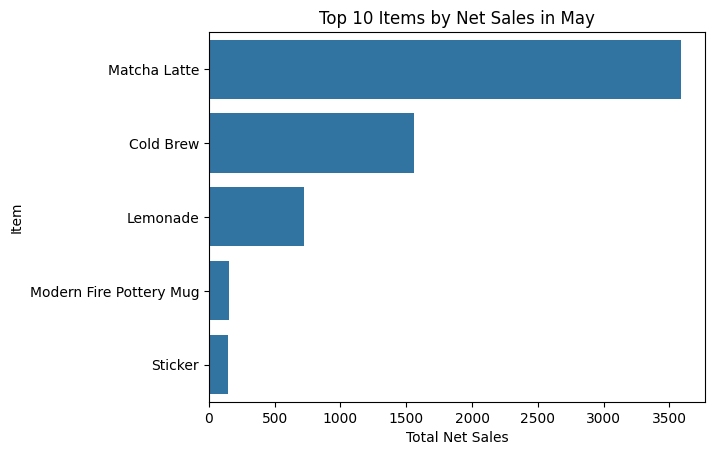

In [150]:
sns.barplot(x=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).values, y=df.groupby("Item")["Net_Sales"].sum().sort_values(ascending=False).head(10).index)
plt.xlabel("Total Net Sales")
plt.ylabel("Item")
plt.title("Top 10 Items by Net Sales in May")
plt.show()

In [151]:
df.groupby("Item")["Qty"].sum().sort_values(ascending=False).head(10)

Item
Matcha Latte               445.0
Cold Brew                  218.0
Lemonade                   162.0
Sticker                     72.0
Modern Fire Pottery Mug      2.0
Name: Qty, dtype: float64

In [152]:
df.groupby("Event_Type")["Net_Sales"].sum().sort_values(ascending=False).head(10)

Event_Type
Market      4743.42
Popup       1364.00
Informal      57.00
Name: Net_Sales, dtype: float64

In [153]:
df["Cold_Foam"].value_counts()

Cold_Foam
False    433
True     365
Name: count, dtype: int64

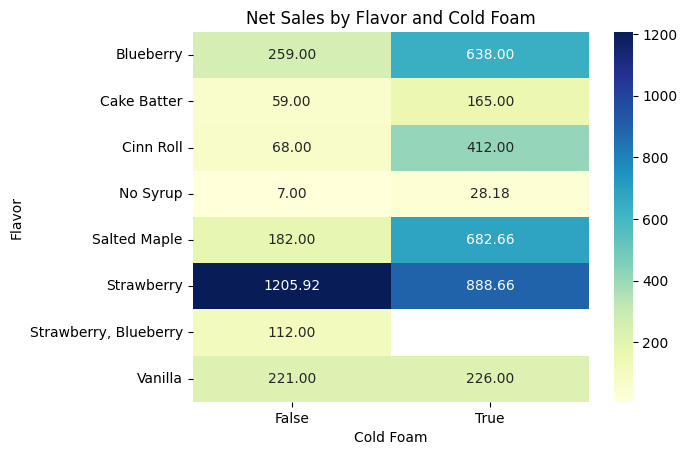

In [154]:
pivot = df.pivot_table(
    index="Flavor",
    columns="Cold_Foam",
    values="Net_Sales",
    aggfunc="sum"
)
sns.heatmap(pivot, annot=True, fmt=".2f", cmap="YlGnBu")
plt.title("Net Sales by Flavor and Cold Foam")
plt.xlabel("Cold Foam")
plt.ylabel("Flavor")
plt.show()

In [155]:
df["Flavor"].value_counts()

Flavor
Strawberry               258
Blueberry                110
Salted Maple             106
Cinn Roll                 56
Vanilla                   53
Cake Batter               23
Strawberry, Blueberry     20
No Syrup                   5
Name: count, dtype: int64

In [156]:
df.groupby("Item")["Net_Sales"].sum() / df.groupby("Item")["Qty"].sum()

Item
Cold Brew                   7.137615
Lemonade                    4.469136
Matcha Latte                8.068360
Modern Fire Pottery Mug    75.000000
Sticker                     2.000000
dtype: float64

In [157]:
pd.crosstab(df["Flavor"], df["Cold_Foam"])

Cold_Foam,False,True
Flavor,,
Blueberry,38,72
Cake Batter,5,18
Cinn Roll,10,46
No Syrup,1,4
Salted Maple,25,81
Strawberry,163,95
"Strawberry, Blueberry",20,0
Vanilla,30,23


In [158]:
df["Base"].value_counts()

Base
Whole Milk    177
Lemonade      173
Oat Milk      108
Name: count, dtype: int64

In [159]:
df.groupby("Base")["Net_Sales"].sum()

Base
Lemonade      1034.18
Oat Milk       912.00
Whole Milk    1565.58
Name: Net_Sales, dtype: float64

In [160]:
pd.crosstab(df["Item"], df["Base"])

Base,Lemonade,Oat Milk,Whole Milk
Item,,,
Cold Brew,0,28,52
Lemonade,134,0,0
Matcha Latte,39,80,125


In [161]:
df.groupby("Item")["Avg_Temp"].mean()

Item
Cold Brew                  80.919192
Lemonade                   82.059701
Matcha Latte               80.740099
Modern Fire Pottery Mug    75.000000
Sticker                    80.300000
Name: Avg_Temp, dtype: float64

In [162]:
df["Hour"] = pd.to_datetime(df["Time"]).dt.hour

/var/folders/w2/4nk24xz14yg09dbpyrxdn4c80000gn/T/ipykernel_63294/816105062.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df["Hour"] = pd.to_datetime(df["Time"]).dt.hour


In [163]:
df.groupby("Hour")["Net_Sales"].sum()

Hour
6      202.00
7       95.00
8      201.00
9     1717.00
10    1389.00
11    1322.42
12     934.00
13     207.00
14      73.00
16      24.00
Name: Net_Sales, dtype: float64

In [164]:
pd.crosstab(df["Hour"], df["Item"])

Item,Cold Brew,Lemonade,Matcha Latte,Modern Fire Pottery Mug,Sticker
Hour,,,,,
6,12,2,13,0,2
7,5,1,7,0,0
8,8,1,14,0,0
9,60,17,115,0,19
10,65,45,70,0,15
11,31,44,85,1,14
12,16,14,75,1,8
13,1,8,17,0,2
14,0,2,7,0,0


In [165]:
df.groupby(
    ["Item","Base","Flavor","Cold_Foam"]
)["Net_Sales"].sum().sort_values(ascending=False)

Item          Base        Flavor                 Cold_Foam
Lemonade      Lemonade    Strawberry             False        360.00
Matcha Latte  Whole Milk  Strawberry             True         317.66
              Lemonade    Strawberry             False        282.00
              Whole Milk  Blueberry              True         228.00
                          Strawberry             False        195.92
Cold Brew     Whole Milk  Salted Maple           True         169.00
Matcha Latte  Oat Milk    Strawberry             True         156.00
                                                 False        137.00
                          Blueberry              True         136.00
Lemonade      Lemonade    Strawberry, Blueberry  False        112.00
Matcha Latte  Whole Milk  Salted Maple           True          96.00
Cold Brew     Oat Milk    Salted Maple           True          92.00
              Whole Milk  Cinn Roll              True          86.00
Matcha Latte  Oat Milk    Salted Maple      

In [166]:
df.groupby(
    ["Item","Base","Flavor","Cold_Foam"]
)["Qty"].sum().sort_values(ascending=False).head(20)

Item          Base        Flavor                 Cold_Foam
Lemonade      Lemonade    Strawberry             False        76.0
Matcha Latte  Lemonade    Strawberry             False        37.0
              Whole Milk  Strawberry             True         37.0
                          Blueberry              True         26.0
                          Strawberry             False        26.0
Lemonade      Lemonade    Strawberry, Blueberry  False        24.0
Cold Brew     Whole Milk  Salted Maple           True         22.0
Matcha Latte  Oat Milk    Strawberry             True         18.0
                                                 False        18.0
Lemonade      Lemonade    Blueberry              False        17.0
Matcha Latte  Oat Milk    Blueberry              True         16.0
Cold Brew     Oat Milk    Salted Maple           True         12.0
Matcha Latte  Oat Milk    Salted Maple           False        11.0
              Whole Milk  Salted Maple           True         11.0
Col

In [167]:
pd.crosstab(
    [df["Item"], df["Base"], df["Flavor"], df["Cold_Foam"]],
    df["Event_Type"],
    values=df["Net_Sales"],
    aggfunc="sum"
)

Event_Type                                               Informal  Market  \
Item         Base       Flavor                Cold_Foam                     
Cold Brew    Oat Milk   Blueberry             True            NaN   14.00   
                        Cake Batter           False           NaN   14.00   
                        Cinn Roll             False           NaN   14.00   
                                              True            NaN   23.00   
                        Salted Maple          False           NaN   12.00   
                                              True            NaN   84.00   
                        Vanilla               False           NaN   28.00   
                                              True            NaN   23.00   
             Whole Milk Blueberry             True            NaN   24.00   
                        Cake Batter           True            NaN    8.00   
                        Cinn Roll             False           NaN   27.00   
                                              True            NaN   55.00   
                        Salted Maple          False           NaN   27.00   
                                              True            NaN  116.00   
                        Vanilla               False           NaN   20.00   
                                              True            NaN   32.00   
Lemonade     Lemonade   Blueberry             False           NaN   72.00   
                                              True            NaN    6.00   
                        Salted Maple          False           5.0     NaN   
                        Strawberry            False           NaN  304.00   
                                              True            NaN    6.00   
                        Strawberry, Blueberry False           NaN  104.00   
Matcha Latte Lemonade   No Syrup              True            NaN   28.18   
                        Strawberry            False           NaN  238.00   
             Oat Milk   Blueberry             False           NaN   44.00   
                                              True            NaN  110.00   
                        Cake Batter           True            NaN   17.00   
                        Cinn Roll             True            NaN     NaN   
                        No Syrup              False           NaN    7.00   
                        Salted Maple          False           NaN    7.00   
                                              True            NaN   36.00   
                        Strawberry            False           NaN   39.00   
                                              True            NaN   80.00   
                        Vanilla               False           NaN   23.00   
                                              True            NaN   25.00   
             Whole Milk Blueberry             False           NaN   31.00   
                                              True            NaN  150.00   
                        Cake Batter           False           NaN   16.00   
                                              True            NaN   52.00   
                        Cinn Roll             False           NaN     NaN   
                                              True            NaN   43.00   
                        Salted Maple          False           NaN     NaN   
                                              True            NaN   87.00   
                        Strawberry            False          24.0   79.92   
                                              True            NaN  224.66   
                        Vanilla               False           NaN   16.00   
                                              True            NaN   27.00   

Event_Type                                               Popup  
Item         Base       Flavor                Cold_Foam         
Cold Brew    Oat Milk   Blueberry             True         NaN  
                        Cake Ba

In [168]:
df.isna().sum()

Date                   0
Time                   0
Original_Item          0
Item                   0
Base                 340
Signature_Drink        0
Qty                    0
Net_Sales              0
Size                 222
Cold_Foam              0
Flavor               167
Avg_Temp               0
Weather_Condition      0
Event_Type             0
Location               0
Hour                   0
dtype: int64

In [169]:
df[df['Base'].isna()]['Item'].value_counts()

Item
Matcha Latte               160
Cold Brew                  118
Sticker                     60
Modern Fire Pottery Mug      2
Name: count, dtype: int64

In [170]:
df[(df['Base'].isna()) & (df['Item'] == 'Matcha Latte')]

,Date,Time,Original_Item,Item,Base,Signature_Drink,Qty,Net_Sales,Size,Cold_Foam,Flavor,Avg_Temp,Weather_Condition,Event_Type,Location,Hour
0,2026-06-16,12:48:11,Matcha Latte,Matcha Latte,NaN,False,1.0,8.0,NaN,True,Strawberry,75,Cloudy,Market,First Flight,12
6,2026-06-16,12:25:25,Matcha Latte,Matcha Latte,NaN,False,1.0,9.0,16oz,True,Strawberry,75,Cloudy,Market,First Flight,12
11,2026-06-16,12:15:21,Matcha Latte,Matcha Latte,NaN,False,1.0,7.0,16oz,False,NaN,75,Cloudy,Market,First Flight,12
12,2026-06-16,12:14:14,Matcha Latte,Matcha Latte,NaN,False,1.0,8.0,NaN,True,Strawberry,75,Cloudy,Market,First Flight,12
13,2026-06-16,12:12:32,Matcha Latte,Matcha Latte,NaN,False,1.0,6.0,NaN,False,NaN,75,Cloudy,Market,First Flight,12
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
768,2026-05-23,09:40:00,Matcha Latte,Matcha Latte,NaN,False,2.0,16.0,12oz,True,NaN,77,Partly Cloudy,Popup,Commercial Kitchen,9
769,2026-05-23,09:38:39,Matcha Latte,Matcha Latte,NaN,False,1.0,9.0,16oz,True,Strawberry,77,Partly Cloudy,Popup,Commercial Kitchen,9
775,2026-05-23,09:35:07,Matcha Latte,Matcha Latte,NaN,False,2.0,14.0,12oz,False,NaN,77,Partly Cloudy,Popup,Commercial Kitchen,9
781,2026-05-23,09:28:24,Matcha Latte,Matcha Latte,NaN,False,2.0,14.0,12oz,False,NaN,77,Partly Cloudy,Popup,Commercial Kitchen,9
